# 모두의 금융 AI 최종 실습
**실습 주제:** 삼성전자·NAVER 데이터 수집 → 전처리 → 수익률·위험 → 50:50 포트폴리오 → 의사결정나무 → LSTM

- 실행 환경: Windows Jupyter Notebook / Python 3.9~3.11 권장
- 기본 실습: 의사결정나무까지 약 20분
- 심화 실습: LSTM 추가 실행
- 학습 목적의 예제이며 실제 투자 판단 자료가 아닙니다.

## 0. 패키지 설치
처음 실행할 때만 아래 셀의 주석을 해제하여 실행합니다. 설치 후 **Kernel → Restart Kernel**을 선택하세요.

TensorFlow 설치가 오래 걸리면 기본 실습을 먼저 진행하고 LSTM 부분은 나중에 실행해도 됩니다.

In [1]:
# 처음 한 번만 실행하세요.
# %pip install -U yfinance pandas numpy matplotlib scikit-learn
# %pip install tensorflow


In [4]:
%pip install -U pykrx pandas numpy matplotlib scikit-learn

  Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl.metadata (59 kB)
Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl (15.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
catboost 1.2.7 requires numpy<2.0,>=1.16.0, but you have numpy 2.0.2 which is incompatible.
numba 0.59.1 requires numpy<1.27,>=1.22, but you have numpy 2.0.2 which is incompatible.
tensorflow-intel 2.15.1 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.0.2 which is incompatible.


## 1. 라이브러리 불러오기 및 그래프 설정

In [5]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from pykrx import stock

# Windows 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.options.display.float_format = "{:,.4f}".format

## 2. 삼성전자와 NAVER 주가 데이터 수집

In [6]:
# ----------------------------------------------------
# 1. 조회 종목과 기간 설정
# ----------------------------------------------------

tickers = {
    "삼성전자": "005930",
    "NAVER": "035420"
}

start_date = "20230101"

# 오늘 날짜를 YYYYMMDD 형태로 변환
end_date = datetime.today().strftime("%Y%m%d")

print("조회 시작일:", start_date)
print("조회 종료일:", end_date)

조회 시작일: 20230101
조회 종료일: 20260804


In [7]:
# ----------------------------------------------------
# 2. pykrx 데이터 수집 함수
# ----------------------------------------------------

def get_stock_data(
    ticker,
    start_date,
    end_date,
    max_retries=3,
    wait_seconds=2
):
    """
    pykrx를 이용하여 개별 종목의 일별 OHLCV 데이터를 가져오는 함수
    """

    last_error = None

    for attempt in range(1, max_retries + 1):

        try:
            df = stock.get_market_ohlcv_by_date(
                fromdate=start_date,
                todate=end_date,
                ticker=ticker,
                freq="d",
                adjusted=True
            )

            if df is None or df.empty:
                raise ValueError(
                    f"{ticker} 데이터가 비어 있습니다."
                )

            # 날짜순 정렬
            df = df.sort_index()

            # 숫자형 변환
            numeric_columns = [
                "시가", "고가", "저가",
                "종가", "거래량"
            ]

            for column in numeric_columns:
                if column in df.columns:
                    df[column] = pd.to_numeric(
                        df[column],
                        errors="coerce"
                    )

            # 종가가 없는 행 제거
            df = df.dropna(subset=["종가"])

            if df.empty:
                raise ValueError(
                    f"{ticker}의 유효한 종가 데이터가 없습니다."
                )

            print(
                f"{ticker} 수집 완료:",
                len(df),
                "개 거래일"
            )

            return df

        except Exception as error:

            last_error = error

            print(
                f"{ticker} 수집 실패 "
                f"({attempt}/{max_retries}):",
                error
            )

            if attempt < max_retries:
                time.sleep(wait_seconds)

    raise RuntimeError(
        f"{ticker} 데이터를 가져오지 못했습니다.\n"
        f"마지막 오류: {last_error}"
    )

In [8]:
# ----------------------------------------------------
# 3. 삼성전자와 NAVER 데이터 수집
# ----------------------------------------------------

stock_data = {}

for name, ticker in tickers.items():

    stock_data[name] = get_stock_data(
        ticker=ticker,
        start_date=start_date,
        end_date=end_date
    )

    # 서버에 연속 요청하는 것을 줄이기 위한 대기
    time.sleep(1)

print("\n데이터 수집 완료")

005930 수집 완료: 875 개 거래일
035420 수집 완료: 875 개 거래일

데이터 수집 완료


## 3. 주가 흐름 확인

In [9]:
print("삼성전자 데이터")
display(stock_data["삼성전자"].head())

print("NAVER 데이터")
display(stock_data["NAVER"].head())

삼성전자 데이터


,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2023-01-02,55500,56100,55200,55500,10031448,0.3617
2023-01-03,55400,56000,54500,55400,13547030,-0.1802
2023-01-04,55700,58000,55600,57800,20188071,4.3321
2023-01-05,58200,58800,57600,58200,15682826,0.6920
2023-01-06,58300,59400,57900,59000,17334989,1.3746


NAVER 데이터


,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2023-01-02,179500,180000,176000,179500,438162,1.1268
2023-01-03,177000,179500,173500,178500,573137,-0.5571
2023-01-04,177000,183500,177000,182500,792920,2.2409
2023-01-05,184500,190000,184000,186000,1107483,1.9178
2023-01-06,185500,187000,182500,185000,741129,-0.5376


In [10]:
print("삼성전자 최근 데이터")
display(stock_data["삼성전자"].tail())

print("NAVER 최근 데이터")
display(stock_data["NAVER"].tail())

삼성전자 최근 데이터


,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2026-07-29,226500,234000,189200,208500,65555523,-5.2273
2026-07-30,214000,226000,202000,207000,46694193,-0.7194
2026-07-31,257000,267000,243000,262500,58478873,26.8116
2026-08-03,248000,249500,238000,239500,27825493,-8.7619
2026-08-04,244500,244500,230500,230500,8617493,-3.7578


NAVER 최근 데이터


,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2026-07-29,213500,213500,194600,201500,1978355,-4.0476
2026-07-30,198500,205500,194100,194700,1680475,-3.3747
2026-07-31,205000,212500,199600,208000,1766586,6.8310
2026-08-03,206500,208500,201500,207500,662318,-0.2404
2026-08-04,219000,231500,215000,225750,1225316,8.7952


## 4. 두 종목의 종가 데이터 결합

In [11]:
# ----------------------------------------------------
# 두 종목의 종가만 하나의 DataFrame으로 결합
# ----------------------------------------------------

close = pd.concat(
    {
        name: df["종가"]
        for name, df in stock_data.items()
    },
    axis=1
)

# 두 종목 모두 거래된 날짜만 사용
close = close.dropna()

print("결합된 데이터 크기:", close.shape)

display(close.head())
display(close.tail())

결합된 데이터 크기: (875, 2)


,삼성전자,NAVER
날짜,,
2023-01-02,55500,179500
2023-01-03,55400,178500
2023-01-04,57800,182500
2023-01-05,58200,186000
2023-01-06,59000,185000


,삼성전자,NAVER
날짜,,
2026-07-29,208500,201500
2026-07-30,207000,194700
2026-07-31,262500,208000
2026-08-03,239500,207500
2026-08-04,230500,225750


## 5. 종가 추이 시각화

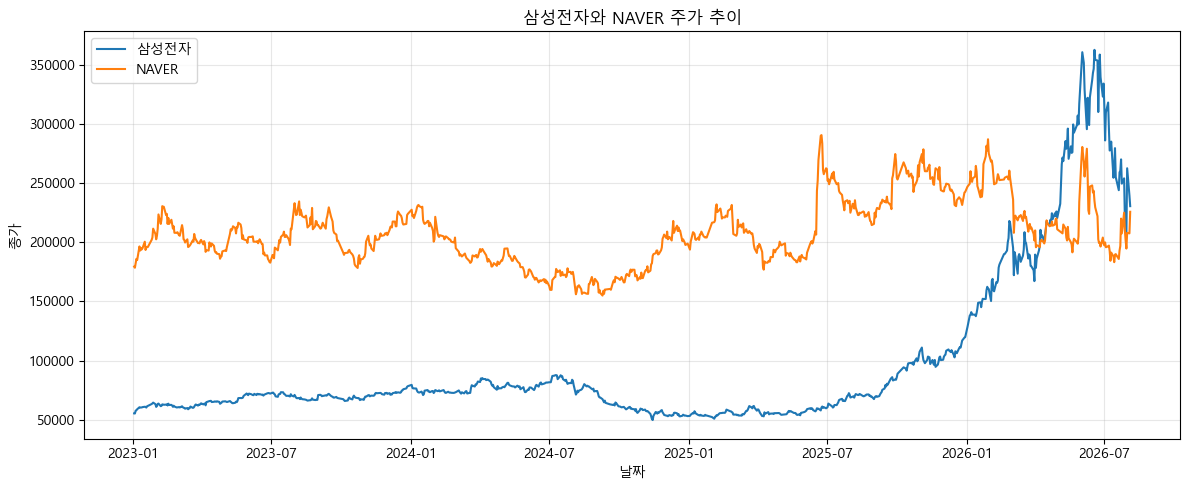

In [12]:
plt.figure(figsize=(12, 5))

for column in close.columns:
    plt.plot(
        close.index,
        close[column],
        label=column
    )

plt.title("삼성전자와 NAVER 주가 추이")
plt.xlabel("날짜")
plt.ylabel("종가")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 두 종목은 주가 수준이 다르기 때문에 직접 비교할 때는 시작 가격을 100으로 표준화하는 것이 더 이해하기 쉽습니다.

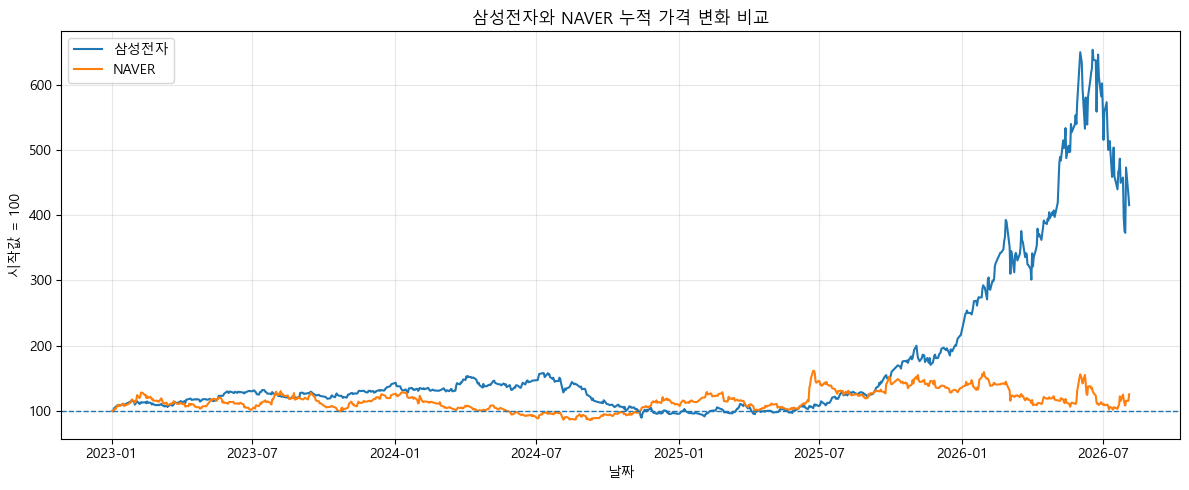

In [13]:
# 시작 가격을 100으로 변환
normalized_price = close / close.iloc[0] * 100

plt.figure(figsize=(12, 5))

for column in normalized_price.columns:
    plt.plot(
        normalized_price.index,
        normalized_price[column],
        label=column
    )

plt.axhline(
    y=100,
    linestyle="--",
    linewidth=1
)

plt.title("삼성전자와 NAVER 누적 가격 변화 비교")
plt.xlabel("날짜")
plt.ylabel("시작값 = 100")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 일별 수익률 계산
- 일별 수익률: 오늘 가격 ÷ 어제 가격 − 1-

In [14]:
returns = close.pct_change().dropna()

display(returns.head())


,삼성전자,NAVER
날짜,,
2023-01-03,-0.0018,-0.0056
2023-01-04,0.0433,0.0224
2023-01-05,0.0069,0.0192
2023-01-06,0.0137,-0.0054
2023-01-09,0.0288,0.0622


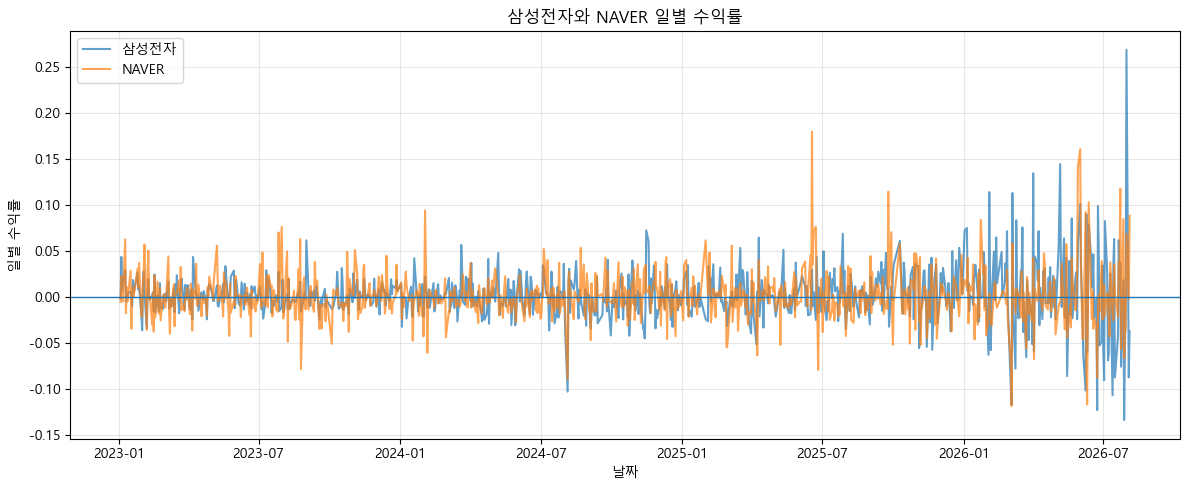

In [15]:
plt.figure(figsize=(12, 5))

for column in returns.columns:
    plt.plot(
        returns.index,
        returns[column],
        label=column,
        alpha=0.7
    )

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("삼성전자와 NAVER 일별 수익률")
plt.xlabel("날짜")
plt.ylabel("일별 수익률")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 연환산 수익률과 위험 계산
- 연환산 기대수익률: 일평균 수익률 × 252


In [16]:
trading_days = 252

# 연환산 평균수익률
annual_return = returns.mean() * trading_days

# 연환산 변동성
annual_risk = returns.std() * np.sqrt(trading_days)

risk_return_table = pd.DataFrame({
    "연환산 수익률": annual_return,
    "연환산 위험": annual_risk
})

risk_return_table["연환산 수익률(%)"] = (
    risk_return_table["연환산 수익률"] * 100
)

risk_return_table["연환산 위험(%)"] = (
    risk_return_table["연환산 위험"] * 100
)

display(
    risk_return_table[
        ["연환산 수익률(%)", "연환산 위험(%)"]
    ].round(2)
)

,연환산 수익률(%),연환산 위험(%)
삼성전자,51.3300,45.6100
NAVER,15.5300,42.5600


In [ ]:
# 단순 평균수익률뿐 아니라 실제 누적성과에 가까운 기하평균 수익률 경우

In [17]:
# 복리 기준 연환산 수익률
compound_annual_return = (
    (1 + returns).prod()
    ** (trading_days / len(returns))
    - 1
)

comparison_table = pd.DataFrame({
    "산술평균 연환산 수익률(%)":
        annual_return * 100,

    "복리 연환산 수익률(%)":
        compound_annual_return * 100,

    "연환산 위험(%)":
        annual_risk * 100
})

display(comparison_table.round(2))

,산술평균 연환산 수익률(%),복리 연환산 수익률(%),연환산 위험(%)
삼성전자,51.3300,50.7600,45.6100
NAVER,15.5300,6.8300,42.5600


## 5. 50:50 포트폴리오 구성
두 종목에 각각 50%씩 투자한다고 가정합니다.

In [18]:
# 삼성전자 50%, NAVER 50%
weights = np.array([0.5, 0.5])

portfolio_return = returns.dot(weights)

portfolio_return.name = "50:50 포트폴리오"

display(portfolio_return.head())


날짜
2023-01-03   -0.0037
2023-01-04    0.0329
2023-01-05    0.0130
2023-01-06    0.0042
2023-01-09    0.0455
Name: 50:50 포트폴리오, dtype: float64

- 포트폴리오 연환산 수익률과 위험
- 연환산 위험: 일별 표준편차 × √252

In [19]:
portfolio_annual_return = (
    portfolio_return.mean() * trading_days
)

portfolio_annual_risk = (
    portfolio_return.std()
    * np.sqrt(trading_days)
)

print(
    "포트폴리오 연환산 수익률:",
    f"{portfolio_annual_return * 100:.2f}%"
)

print(
    "포트폴리오 연환산 위험:",
    f"{portfolio_annual_risk * 100:.2f}%"
)

포트폴리오 연환산 수익률: 33.43%
포트폴리오 연환산 위험: 36.10%


- 포트폴리오 위험을 공분산 행렬로 계산

In [20]:
# 연환산 공분산 행렬
annual_covariance = (
    returns.cov() * trading_days
)

portfolio_variance = (
    weights.T
    @ annual_covariance.values
    @ weights
)

portfolio_risk_cov = np.sqrt(
    portfolio_variance
)

print(
    "공분산 행렬로 계산한 포트폴리오 위험:",
    f"{portfolio_risk_cov * 100:.2f}%"
)

공분산 행렬로 계산한 포트폴리오 위험: 36.10%


- 개별 종목과 포트폴리오 비교

In [21]:
result_table = pd.DataFrame({
    "연환산 수익률(%)": [
        annual_return["삼성전자"] * 100,
        annual_return["NAVER"] * 100,
        portfolio_annual_return * 100
    ],

    "연환산 위험(%)": [
        annual_risk["삼성전자"] * 100,
        annual_risk["NAVER"] * 100,
        portfolio_annual_risk * 100
    ]
}, index=[
    "삼성전자",
    "NAVER",
    "50:50 포트폴리오"
])

display(result_table.round(2))

,연환산 수익률(%),연환산 위험(%)
삼성전자,51.3300,45.6100
NAVER,15.5300,42.5600
50:50 포트폴리오,33.4300,36.1000


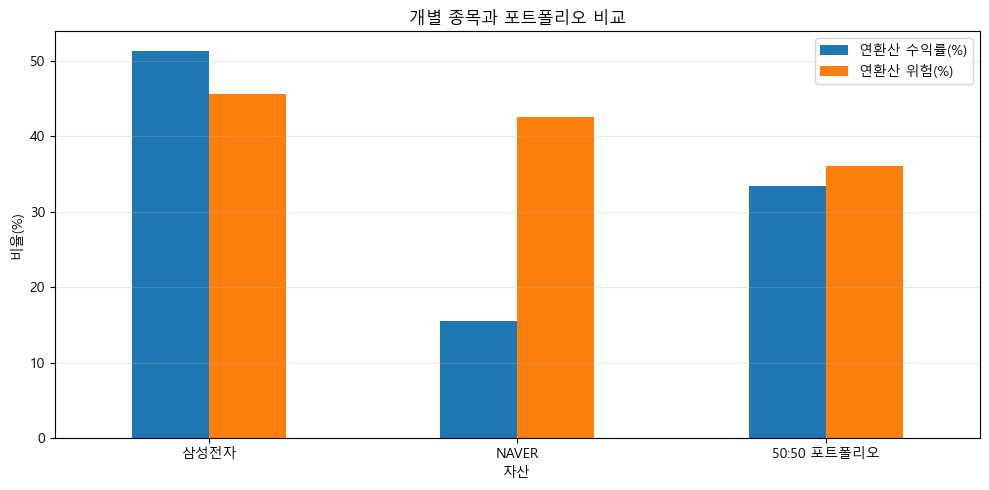

In [22]:
result_table.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("개별 종목과 포트폴리오 비교")
plt.xlabel("자산")
plt.ylabel("비율(%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 10. 누적수익률 비교

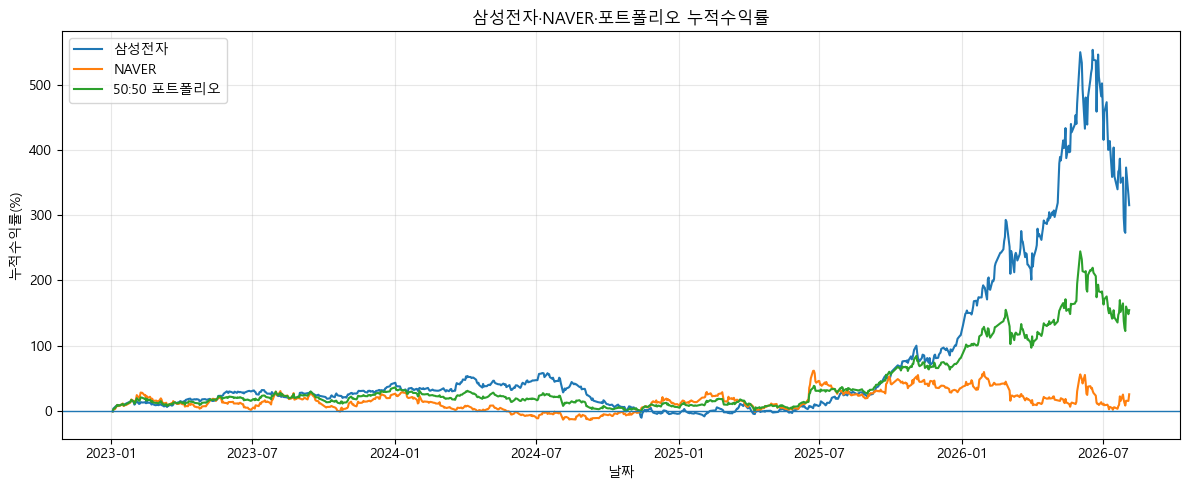

In [23]:
asset_and_portfolio_returns = returns.copy()

asset_and_portfolio_returns[
    "50:50 포트폴리오"
] = portfolio_return

cumulative_returns = (
    1 + asset_and_portfolio_returns
).cumprod() - 1

plt.figure(figsize=(12, 5))

for column in cumulative_returns.columns:
    plt.plot(
        cumulative_returns.index,
        cumulative_returns[column] * 100,
        label=column
    )

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("삼성전자·NAVER·포트폴리오 누적수익률")
plt.xlabel("날짜")
plt.ylabel("누적수익률(%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- 삼성전자 예측용 Feature와 Target 만들기
**Feature**
- 전일 수익률
- 5일 이동평균 대비 가격 차이
- 20일 이동평균 대비 가격 차이
- 최근 5일 변동성
- 거래량 변화율

**Target**
- 다음 거래일 상승: 1
- 다음 거래일 보합 또는 하락: 0

## 11. 삼성전자 머신러닝 데이터 생성

In [25]:
# 삼성전자 OHLCV 데이터 복사
samsung = stock_data["삼성전자"].copy()

print("삼성전자 원본 데이터")
display(samsung.head())

삼성전자 원본 데이터


,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2023-01-02,55500,56100,55200,55500,10031448,0.3617
2023-01-03,55400,56000,54500,55400,13547030,-0.1802
2023-01-04,55700,58000,55600,57800,20188071,4.3321
2023-01-05,58200,58800,57600,58200,15682826,0.6920
2023-01-06,58300,59400,57900,59000,17334989,1.3746


### 11-1. Feature 생성

In [26]:
# 일별 수익률
samsung["수익률"] = samsung["종가"].pct_change()

# 이동평균
samsung["MA5"] = samsung["종가"].rolling(window=5).mean()
samsung["MA20"] = samsung["종가"].rolling(window=20).mean()

# 이동평균 대비 현재 주가 비율
samsung["종가_MA5비율"] = samsung["종가"] / samsung["MA5"] - 1
samsung["종가_MA20비율"] = samsung["종가"] / samsung["MA20"] - 1

# 최근 5일 변동성
samsung["변동성5"] = samsung["수익률"].rolling(window=5).std()

# 거래량 변화율
samsung["거래량변화율"] = samsung["거래량"].pct_change()

# 당일 고가와 저가 차이
samsung["고저가변동률"] = (
    samsung["고가"] - samsung["저가"]
) / samsung["종가"]

# 다음 거래일 수익률
samsung["다음날수익률"] = samsung["수익률"].shift(-1)

# 다음날 상승 여부
# 상승: 1, 하락 또는 보합: 0
samsung["Target"] = (
    samsung["다음날수익률"] > 0
).astype(int)

# 무한대 값을 결측값으로 변경
samsung = samsung.replace(
    [np.inf, -np.inf],
    np.nan
)

# 결측값 제거
samsung = samsung.dropna()

print("Feature 생성 후 데이터 크기:", samsung.shape)

display(samsung.head())

Feature 생성 후 데이터 크기: (855, 16)


,시가,고가,저가,종가,거래량,등락률,수익률,MA5,MA20,종가_MA5비율,종가_MA20비율,변동성5,거래량변화율,고저가변동률,다음날수익률,Target
날짜,,,,,,,,,,,,,,,,
2023-01-31,63500,63700,61000,61000,29746731,-3.6335,-0.0363,"63,240.0000","60,540.0000",-0.0354,0.0076,0.0252,0.4168,0.0443,0.0131,1
2023-02-01,62600,62700,61000,61800,18570133,1.3115,0.0131,"62,920.0000","60,855.0000",-0.0178,0.0155,0.0221,-0.3757,0.0275,0.0275,1
2023-02-02,63200,63900,62600,63500,23285983,2.7508,0.0275,"62,840.0000","61,260.0000",0.0105,0.0366,0.0263,0.2539,0.0205,0.0047,1
2023-02-03,63900,64000,63000,63800,15194598,0.4724,0.0047,"62,680.0000","61,560.0000",0.0179,0.0364,0.0257,-0.3475,0.0157,-0.0345,0
2023-02-06,62800,63000,61600,61600,15529356,-3.4483,-0.0345,"62,340.0000","61,730.0000",-0.0119,-0.0021,0.0289,0.0220,0.0227,0.0049,1


## 12. 입력변수와 목표변수 설정

In [27]:
features = [
    "수익률",
    "종가_MA5비율",
    "종가_MA20비율",
    "변동성5",
    "거래량변화율",
    "고저가변동률"
]

X = samsung[features]
y = samsung["Target"]

print("입력 데이터 크기:", X.shape)
print("목표 데이터 크기:", y.shape)

display(X.head())

입력 데이터 크기: (855, 6)
목표 데이터 크기: (855,)


,수익률,종가_MA5비율,종가_MA20비율,변동성5,거래량변화율,고저가변동률
날짜,,,,,,
2023-01-31,-0.0363,-0.0354,0.0076,0.0252,0.4168,0.0443
2023-02-01,0.0131,-0.0178,0.0155,0.0221,-0.3757,0.0275
2023-02-02,0.0275,0.0105,0.0366,0.0263,0.2539,0.0205
2023-02-03,0.0047,0.0179,0.0364,0.0257,-0.3475,0.0157
2023-02-06,-0.0345,-0.0119,-0.0021,0.0289,0.0220,0.0227


### 12.1상승·하락 비율 확인

In [28]:
target_ratio = y.value_counts().sort_index()

target_ratio.index = [
    "하락·보합(0)",
    "상승(1)"
]

display(target_ratio.to_frame("관측치 수"))

,관측치 수
하락·보합(0),428
상승(1),427


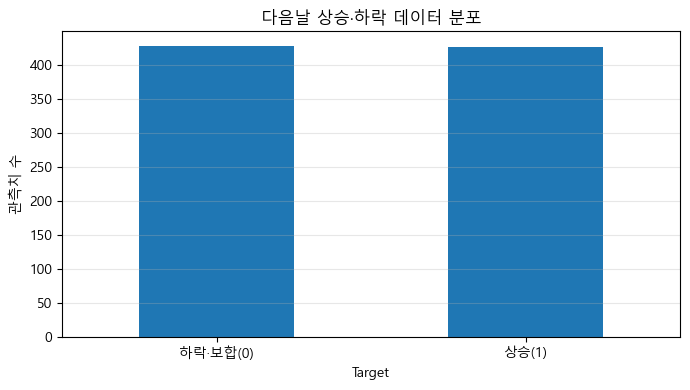

In [29]:
target_ratio.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("다음날 상승·하락 데이터 분포")
plt.xlabel("Target")
plt.ylabel("관측치 수")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 13. 학습 데이터와 평가 데이터 분리

In [30]:
# 앞의 80%를 학습 데이터,
# 뒤의 20%를 평가 데이터로 사용
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("학습기간")
print(X_train.index.min(), "~", X_train.index.max())

print("\n평가기간")
print(X_test.index.min(), "~", X_test.index.max())

print("\n학습 데이터:", X_train.shape)
print("평가 데이터:", X_test.shape)

학습기간
2023-01-31 00:00:00 ~ 2025-11-19 00:00:00

평가기간
2025-11-20 00:00:00 ~ 2026-08-03 00:00:00

학습 데이터: (684, 6)
평가 데이터: (171, 6)


## 14. 의사결정나무 분류모델 학습

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=10,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_pred = tree_model.predict(X_test)

print("의사결정나무 학습 완료")

의사결정나무 학습 완료


## 15. 의사결정나무 성능평가와 Feature Importance

In [32]:
tree_accuracy = accuracy_score(
    y_test,
    tree_pred
)

tree_precision = precision_score(
    y_test,
    tree_pred,
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    tree_pred,
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    tree_pred,
    zero_division=0
)

print(
    f"Accuracy : {tree_accuracy:.4f}"
)

print(
    f"Precision: {tree_precision:.4f}"
)

print(
    f"Recall   : {tree_recall:.4f}"
)

print(
    f"F1-score : {tree_f1:.4f}"
)

Accuracy : 0.5029
Precision: 0.5455
Recall   : 0.6875
F1-score : 0.6083


### 15.1 분류 결과표

In [33]:
print(
    classification_report(
        y_test,
        tree_pred,
        target_names=[
            "하락·보합",
            "상승"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

       하락·보합       0.40      0.27      0.32        75
          상승       0.55      0.69      0.61        96

    accuracy                           0.50       171
   macro avg       0.47      0.48      0.46       171
weighted avg       0.48      0.50      0.48       171



### 15.2 혼동행렬

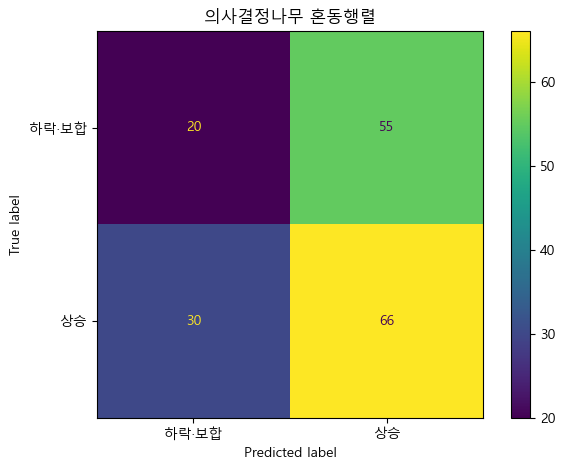

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    tree_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "하락·보합",
        "상승"
    ]
)

disp.plot(
    values_format="d"
)

plt.title("의사결정나무 혼동행렬")
plt.tight_layout()
plt.show()

### 15.3 의사결정나무 시각화

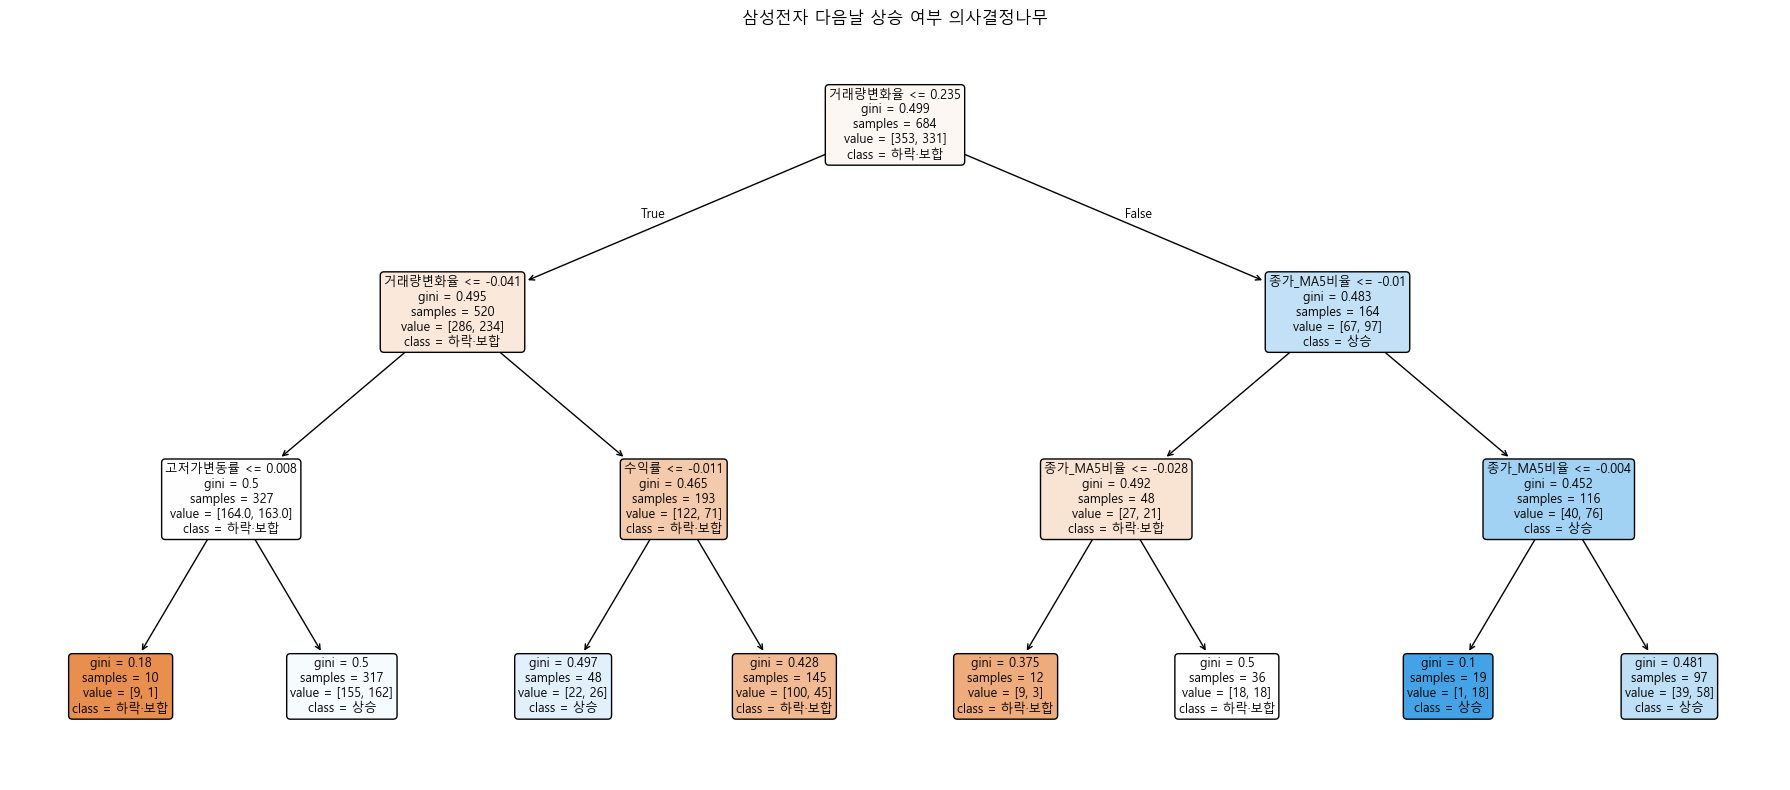

In [35]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))

plot_tree(
    tree_model,
    feature_names=features,
    class_names=[
        "하락·보합",
        "상승"
    ],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("삼성전자 다음날 상승 여부 의사결정나무")
plt.tight_layout()
plt.show()

### 15.4 Feature Importance 확인

In [36]:
feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=features
).sort_values(ascending=False)

display(
    feature_importance.to_frame(
        "중요도"
    )
)

,중요도
거래량변화율,0.3728
종가_MA5비율,0.3358
수익률,0.1576
고저가변동률,0.1338
종가_MA20비율,0.0000
변동성5,0.0000


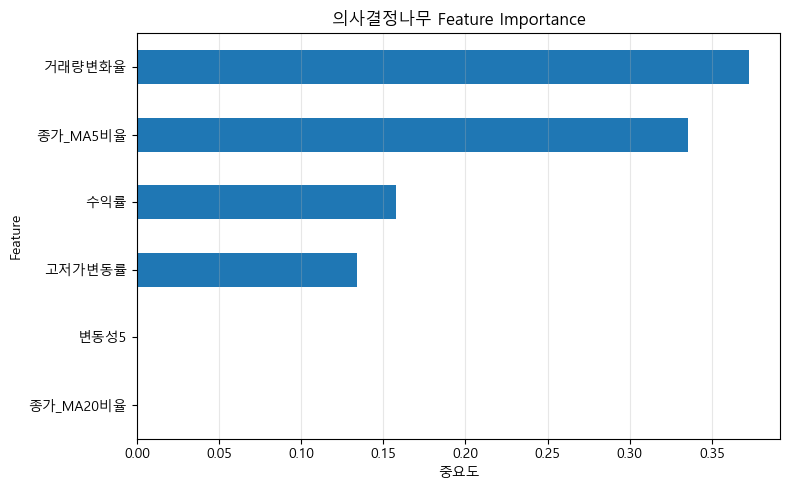

In [37]:
feature_importance.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("의사결정나무 Feature Importance")
plt.xlabel("중요도")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

- 중요도가 높다는 것은 의사결정나무가 상승과 하락을 구분할 때 해당 변수를 상대적으로 많이 활용했다는 의미입니다. 
- 인과관계를 의미하지는 않습니다.

### 15.5 실제값과 예측값 비교

In [38]:
tree_result = pd.DataFrame({
    "실제값": y_test,
    "예측값": tree_pred
}, index=y_test.index)

tree_result["예측정확"] = (
    tree_result["실제값"]
    == tree_result["예측값"]
)

display(tree_result.head(20))

,실제값,예측값,예측정확
날짜,,,
2025-11-20,0,1,False
2025-11-21,1,1,True
2025-11-24,1,1,True
2025-11-25,1,1,True
2025-11-26,1,1,True
2025-11-27,0,1,False
2025-11-28,1,1,True
2025-12-01,1,1,True
2025-12-02,1,1,True


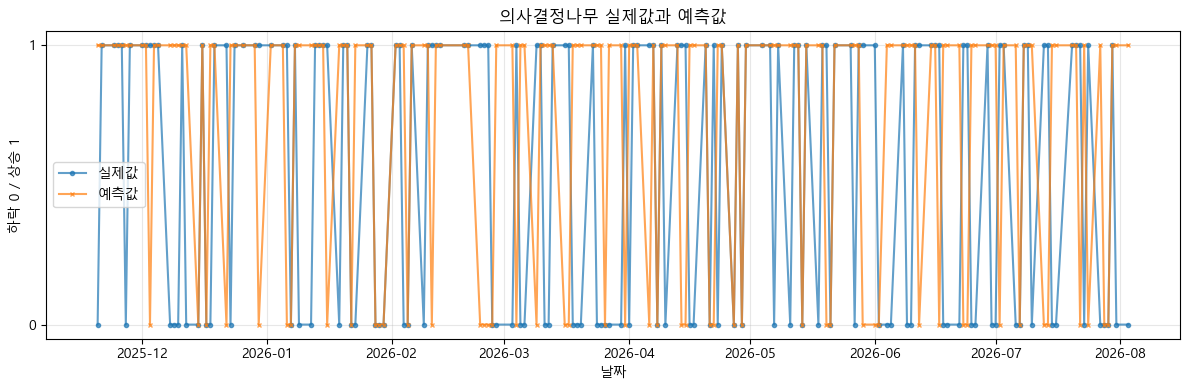

In [39]:
plt.figure(figsize=(12, 4))

plt.plot(
    tree_result.index,
    tree_result["실제값"],
    label="실제값",
    marker="o",
    markersize=3,
    alpha=0.7
)

plt.plot(
    tree_result.index,
    tree_result["예측값"],
    label="예측값",
    marker="x",
    markersize=3,
    alpha=0.7
)

plt.title("의사결정나무 실제값과 예측값")
plt.xlabel("날짜")
plt.ylabel("하락 0 / 상승 1")
plt.yticks([0, 1])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 심화 실습: LSTM
LSTM은 최근 여러 거래일의 Feature 흐름을 한 묶음(sequence)으로 학습합니다. 30분 수업에서는 구조와 결과만 소개하고, 학습은 선택적으로 실행할 수 있습니다.

## 16. LSTM 실습 준비

In [ ]:
# LSTM을 실행하려면 TensorFlow가 필요합니다. 설치되지 않았다면 다음 셀의 주석을 제거해 실행합니다.

# %pip install tensorflow

# 설치 후에는 다음을 실행합니다.

# Kernel → Restart Kernel

# 그리고 노트북의 라이브러리 셀부터 다시 실행합니다.

In [ ]:
## 21. LSTM 라이브러리 불러오기

In [40]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler

print("TensorFlow 버전:", tf.__version__)

# 결과 재현을 위한 난수 고정
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow 버전: 2.15.1


## 17. LSTM 학습 데이터 준비

- LSTM에는 최근 일정 기간의 데이터를 하나의 입력 묶음으로 제공합니다.
- 예를 들어 최근 20일 데이터를 이용하여 다음날 상승 여부를 예측합니다.

In [41]:
lstm_features = [
    "수익률",
    "종가_MA5비율",
    "종가_MA20비율",
    "변동성5",
    "거래량변화율",
    "고저가변동률"
]

lstm_X_original = samsung[
    lstm_features
].copy()

lstm_y_original = samsung[
    "Target"
].copy()

### 학습·평가 구간 분리

In [42]:
split_index = int(
    len(lstm_X_original) * 0.8
)

X_train_raw = lstm_X_original.iloc[
    :split_index
].copy()

X_test_raw = lstm_X_original.iloc[
    split_index:
].copy()

y_train_raw = lstm_y_original.iloc[
    :split_index
].copy()

y_test_raw = lstm_y_original.iloc[
    split_index:
].copy()

print("LSTM 학습 데이터:", X_train_raw.shape)
print("LSTM 평가 데이터:", X_test_raw.shape)

LSTM 학습 데이터: (684, 6)
LSTM 평가 데이터: (171, 6)


## 18. Feature 표준화

- 표준화 기준은 학습 데이터에서만 계산합니다.

In [43]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_raw
)

X_test_scaled = scaler.transform(
    X_test_raw
)

print("표준화 완료")

표준화 완료


## 19. LSTM 시퀀스 데이터 생성

In [48]:
sequence_length = 20

X_train_lstm, y_train_lstm = create_sequences(
    X_train_scaled,
    y_train_raw,
    sequence_length
)

X_test_lstm, y_test_lstm = create_sequences(
    X_test_scaled,
    y_test_raw,
    sequence_length
)

In [49]:
def create_sequences(
    X,
    y,
    sequence_length=20
):
    """
    과거 sequence_length일의 데이터로
    다음 시점의 Target을 예측하도록 데이터를 구성
    """

    X_sequences = []
    y_sequences = []

    for i in range(
        sequence_length,
        len(X)
    ):
        X_sequences.append(
            X[
                i-sequence_length:i
            ]
        )

        y_sequences.append(
            y.iloc[i]
        )

    return (
        np.array(X_sequences),
        np.array(y_sequences)
    )

In [50]:
# 최근 20일 데이터를 한 묶음으로 사용
sequence_length = 20

# 입력 Feature 개수
n_features = len(lstm_features)

lstm_model = Sequential([
    Input(
        shape=(
            sequence_length,
            n_features
        )
    ),

    LSTM(
        units=32,
        return_sequences=False
    ),

    Dropout(0.2),

    Dense(
        units=16,
        activation="relu"
    ),

    Dropout(0.2),

    Dense(
        units=1,
        activation="sigmoid"
    )
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 32)                4992      
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dropout_3 (Dropout)         (None, 16)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 5537 (21.63 KB)
Trainable params: 5537 (21.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# 입력 데이터의 구조는 다음과 같습니다.
# 샘플 수 × 과거 기간 × Feature 수
# 예를 들면 다음과 같습니다.
# 500 × 20 × 6


## 20. LSTM 모델 생성

In [51]:
lstm_model = Sequential([
    Input(
        shape=(
            sequence_length,
            len(lstm_features)
        )
    ),

    LSTM(
        units=32,
        return_sequences=False
    ),

    Dropout(0.2),

    Dense(
        units=16,
        activation="relu"
    ),

    Dropout(0.2),

    Dense(
        units=1,
        activation="sigmoid"
    )
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 32)                4992      
                                                                 
 dropout_4 (Dropout)         (None, 32)                0         
                                                                 
 dense_4 (Dense)             (None, 16)                528       
                                                                 
 dropout_5 (Dropout)         (None, 16)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                 17        
                                                                 
Total params: 5537 (21.63 KB)
Trainable params: 5537 (21.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 21. LSTM 모델 학습

In [ ]:
# shuffle=False는 시계열 데이터의 순서를 유지하기 위한 설정입니다.

In [52]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30


17/17 [==============================] - 5s 55ms/step - loss: 0.6894 - accuracy: 0.5273 - val_loss: 0.7170 - val_accuracy: 0.4586
Epoch 2/30
17/17 [==============================] - 0s 11ms/step - loss: 0.6875 - accuracy: 0.5612 - val_loss: 0.7278 - val_accuracy: 0.4361
Epoch 3/30
17/17 [==============================] - 0s 9ms/step - loss: 0.6856 - accuracy: 0.5574 - val_loss: 0.7383 - val_accuracy: 0.4436
Epoch 4/30
17/17 [==============================] - 0s 10ms/step - loss: 0.6754 - accuracy: 0.5876 - val_loss: 0.7541 - val_accuracy: 0.4436
Epoch 5/30
17/17 [==============================] - 0s 9ms/step - loss: 0.6829 - accuracy: 0.5669 - val_loss: 0.7691 - val_accuracy: 0.4436
Epoch 6/30
17/17 [==============================] - 0s 10ms/step - loss: 0.6741 - accuracy: 0.6045 - val_loss: 0.7792 - val_accuracy: 0.4436


## 22. LSTM 학습 과정 시각화

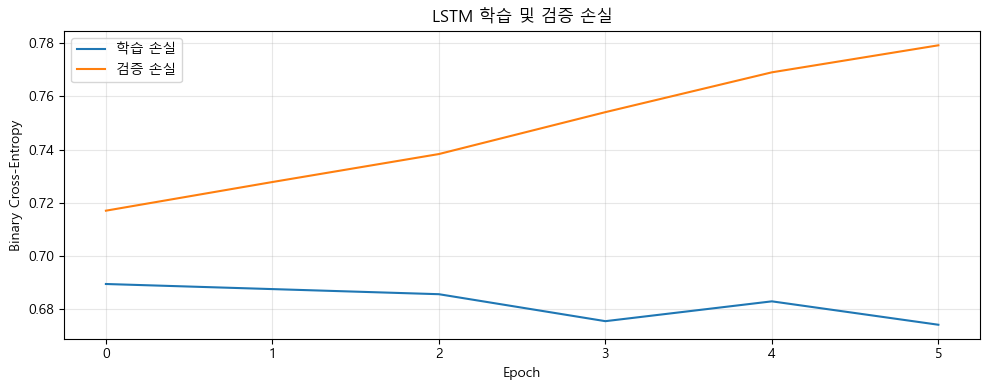

In [53]:
plt.figure(figsize=(10, 4))

plt.plot(
    history.history["loss"],
    label="학습 손실"
)

plt.plot(
    history.history["val_loss"],
    label="검증 손실"
)

plt.title("LSTM 학습 및 검증 손실")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 22.1 정확도

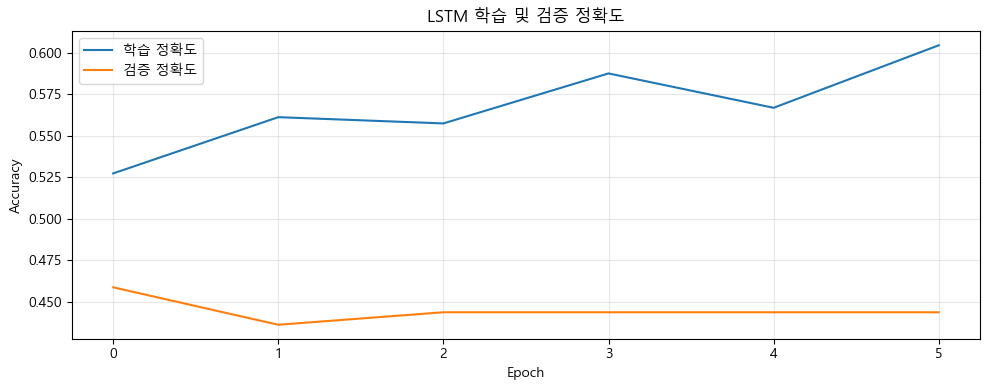

In [54]:
plt.figure(figsize=(10, 4))

plt.plot(
    history.history["accuracy"],
    label="학습 정확도"
)

plt.plot(
    history.history["val_accuracy"],
    label="검증 정확도"
)

plt.title("LSTM 학습 및 검증 정확도")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 23. LSTM 예측

In [55]:
lstm_probability = (
    lstm_model.predict(
        X_test_lstm,
        verbose=0
    ).flatten()
)

# 상승확률이 0.5 이상이면 상승으로 분류
lstm_pred = (
    lstm_probability >= 0.5
).astype(int)

print("LSTM 예측 완료")

LSTM 예측 완료


## 24. LSTM 성능평가

In [56]:
lstm_accuracy = accuracy_score(
    y_test_lstm,
    lstm_pred
)

lstm_precision = precision_score(
    y_test_lstm,
    lstm_pred,
    zero_division=0
)

lstm_recall = recall_score(
    y_test_lstm,
    lstm_pred,
    zero_division=0
)

lstm_f1 = f1_score(
    y_test_lstm,
    lstm_pred,
    zero_division=0
)

print(
    f"Accuracy : {lstm_accuracy:.4f}"
)

print(
    f"Precision: {lstm_precision:.4f}"
)

print(
    f"Recall   : {lstm_recall:.4f}"
)

print(
    f"F1-score : {lstm_f1:.4f}"
)

Accuracy : 0.4371
Precision: 0.4878
Recall   : 0.2381
F1-score : 0.3200


In [57]:
print(
    classification_report(
        y_test_lstm,
        lstm_pred,
        target_names=[
            "하락·보합",
            "상승"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

       하락·보합       0.42      0.69      0.52        67
          상승       0.49      0.24      0.32        84

    accuracy                           0.44       151
   macro avg       0.45      0.46      0.42       151
weighted avg       0.46      0.44      0.41       151



## 25. LSTM 혼동행렬

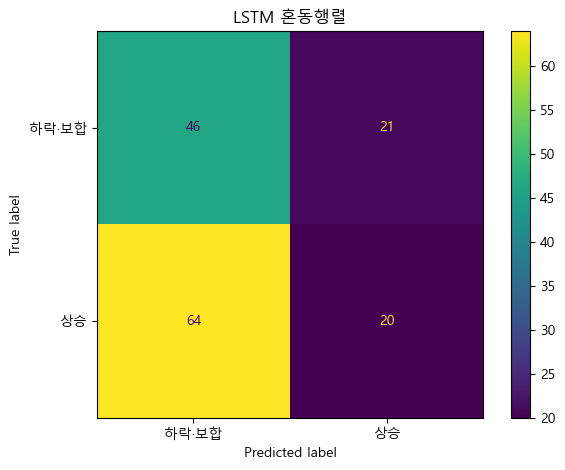

In [58]:
lstm_cm = confusion_matrix(
    y_test_lstm,
    lstm_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=lstm_cm,
    display_labels=[
        "하락·보합",
        "상승"
    ]
)

disp.plot(
    values_format="d"
)

plt.title("LSTM 혼동행렬")
plt.tight_layout()
plt.show()

## 26. 상승확률과 실제값 비교

In [59]:
lstm_test_dates = (
    y_test_raw.index[
        sequence_length:
    ]
)

lstm_result = pd.DataFrame({
    "실제값": y_test_lstm,
    "예측값": lstm_pred,
    "상승예측확률": lstm_probability
}, index=lstm_test_dates)

display(lstm_result.head(20))

,실제값,예측값,상승예측확률
날짜,,,
2025-12-18,0,0,0.4657
2025-12-19,1,0,0.4691
2025-12-22,1,0,0.4720
2025-12-23,0,0,0.4797
2025-12-24,1,0,0.4800
2025-12-26,1,0,0.4819
2025-12-29,1,0,0.4748
2025-12-30,1,0,0.4449
2026-01-02,1,0,0.4574


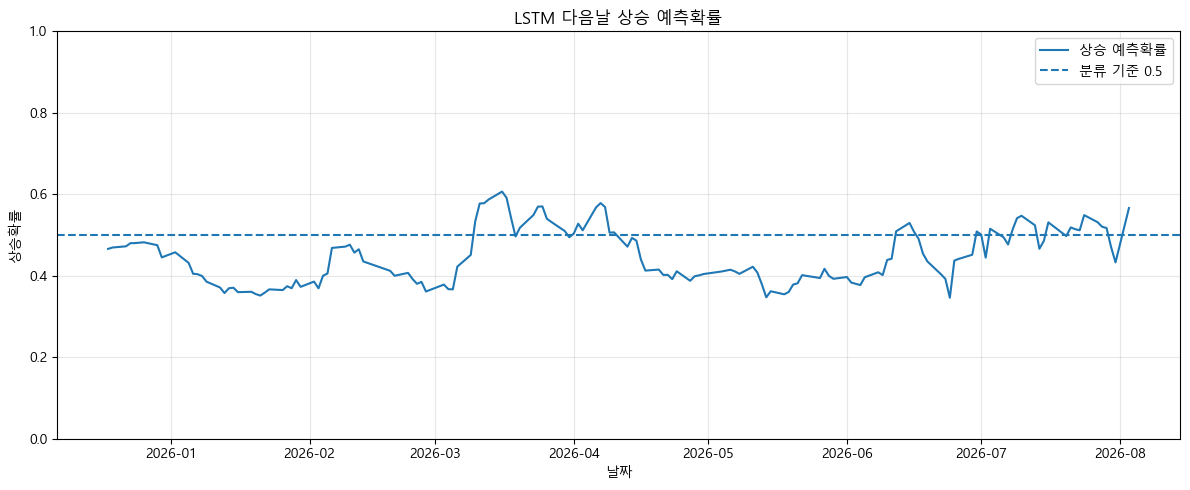

In [60]:
plt.figure(figsize=(12, 5))

plt.plot(
    lstm_result.index,
    lstm_result["상승예측확률"],
    label="상승 예측확률"
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="분류 기준 0.5"
)

plt.title("LSTM 다음날 상승 예측확률")
plt.xlabel("날짜")
plt.ylabel("상승확률")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 27. 의사결정나무와 LSTM 비교

In [ ]:
#두 모델은 평가 대상 날짜가 다를 수 있으므로 각각의 평가 결과를 비교합니다.

In [61]:
model_comparison = pd.DataFrame({
    "Accuracy": [
        tree_accuracy,
        lstm_accuracy
    ],

    "Precision": [
        tree_precision,
        lstm_precision
    ],

    "Recall": [
        tree_recall,
        lstm_recall
    ],

    "F1-score": [
        tree_f1,
        lstm_f1
    ]
}, index=[
    "Decision Tree",
    "LSTM"
])

display(
    model_comparison.round(4)
)

,Accuracy,Precision,Recall,F1-score
Decision Tree,0.5029,0.5455,0.6875,0.6083
LSTM,0.4371,0.4878,0.2381,0.3200


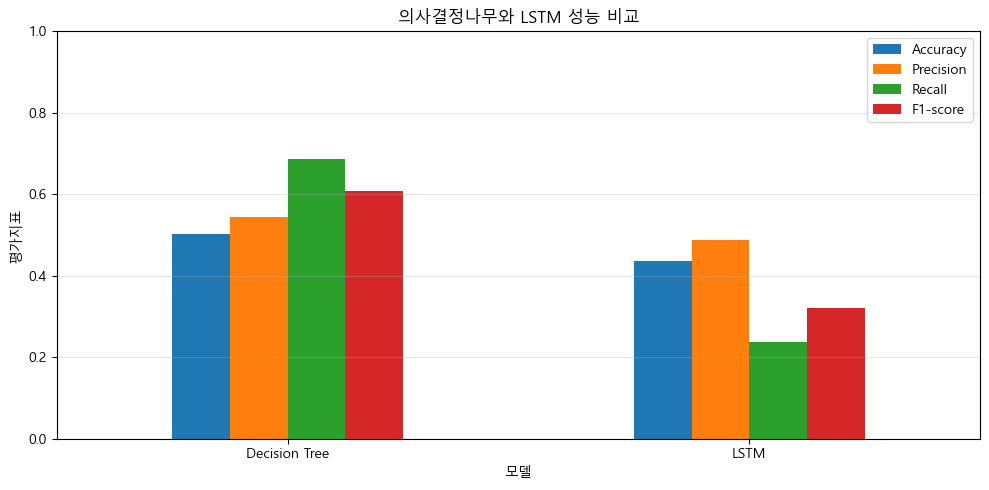

In [62]:
model_comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("의사결정나무와 LSTM 성능 비교")
plt.xlabel("모델")
plt.ylabel("평가지표")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 28. 최종 결과 해석

In [63]:
best_accuracy_model = (
    model_comparison["Accuracy"].idxmax()
)

best_f1_model = (
    model_comparison["F1-score"].idxmax()
)

print(
    "Accuracy가 높은 모델:",
    best_accuracy_model
)

print(
    "F1-score가 높은 모델:",
    best_f1_model
)

Accuracy가 높은 모델: Decision Tree
F1-score가 높은 모델: Decision Tree


- 의사결정나무는 구조와 Feature Importance를 쉽게 설명할 수 있습니다.
- LSTM은 최근 20일처럼 연속된 시계열 정보를 학습합니다.
- 정확도가 50% 부근이라도 이상한 결과는 아닙니다.
- 주식의 단기 방향은 잡음과 예측 불가능성이 크기 때문입니다.
- 높은 학습 정확도만 보고 좋은 모델이라고 판단하면 안 됩니다.
- 실제 투자에는 거래비용, 과적합, 미래정보 사용 여부 등을 추가로 검토해야 합니다.